In [16]:
from torchvision import transforms

In [17]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [18]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
from PIL import Image
import numpy as np

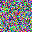

In [20]:
fake_img = Image.fromarray(np.random.randint(0, 255, (32, 32, 3), dtype=np.uint8))
fake_img

In [21]:
tensor_img = train_transform(fake_img)

In [22]:
print(f"变换后形状: {tensor_img.shape}")

变换后形状: torch.Size([3, 32, 32])


In [23]:
print(f"值范围: [{tensor_img.min():.2f}, {tensor_img.max():.2f}]")

值范围: [-2.12, 2.27]


In [24]:
from torch.utils.data import DataLoader
from torchvision import datasets

In [25]:
raw_transform = transforms.Compose([transforms.ToTensor()])

In [26]:
dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=raw_transform,
)
loader = DataLoader(dataset, batch_size=1000)

In [27]:
import torch

In [28]:
mean = torch.zeros(3)
std = torch.zeros(3)

In [29]:
for images, _ in loader:
    mean += images.mean(dim=[0, 2, 3])
    std += images.std(dim=[0, 2, 3])

mean /= len(loader)
std /= len(loader)

In [30]:
print(f"数据集 mean: {mean.tolist()}")
print(f"数据集 std: {std.tolist()}")

数据集 mean: [0.4913996756076813, 0.4821584224700928, 0.4465310275554657]
数据集 std: [0.24698609113693237, 0.24344448745250702, 0.26152947545051575]
